In [1]:
# References / notes:
# - Uses the same derived-dir contract as Endymion's DataHandler:
#   persistent/derived/<tile_id>/roi_<r0>_<r1>_<c0>_<c1>
# - This avoids hardcoding a path that may not match the cache root used by the benchmark.

from pathlib import Path
import numpy as np

# --- Match the exact cache root used by your successful local runs ---
PERSISTENT_DIR = Path(r"C:\Endymion\persistent")
TILE_ID = "ldem_80s_20m"
ROI = (14688, 15712, 14688, 15712)

def roi_key(roi):
    r0, r1, c0, c1 = roi
    return f"roi_{r0}_{r1}_{c0}_{c1}"

base_dir = PERSISTENT_DIR / "derived" / TILE_ID / roi_key(ROI)

print("Base dir:", base_dir)
print("Base dir exists:", base_dir.exists())

if base_dir.exists():
    print("\nFiles in derived dir:")
    for p in sorted(base_dir.iterdir()):
        print(" -", p.name)

dem_path = base_dir / "dem_m.npy"
mask_path = base_dir / "crater_mask.npy"
proba_path = base_dir / "crater_proba_ml_v1.npy"

print("\ndem exists:", dem_path.exists(), dem_path)
print("mask exists:", mask_path.exists(), mask_path)
print("proba exists:", proba_path.exists(), proba_path)

# Load only if all required files exist
assert dem_path.exists(), f"Missing DEM raster: {dem_path}"
assert mask_path.exists(), f"Missing crater mask: {mask_path}"
assert proba_path.exists(), f"Missing ML raster: {proba_path}"

dem_m = np.load(dem_path)
crater_mask = np.load(mask_path)
crater_proba = np.load(proba_path)

print("\nLoaded shapes:")
print("DEM:", dem_m.shape)
print("Mask:", crater_mask.shape)
print("Proba:", crater_proba.shape)

Base dir: C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712
Base dir exists: True

Files in derived dir:
 - benchmarks
 - crater_mask.npy
 - crater_mask_density.npy
 - crater_mask_distance.npy
 - crater_mask_meta.json
 - crater_proba_ml_v1.npy
 - crater_proba_ml_v1_feature_importances.json
 - crater_proba_ml_v1_summary.json
 - dem_m.npy
 - meta.json
 - ml_dataset_rf_v1.csv
 - navigation
 - rf_crater_model_v1.joblib
 - roughness_rms.npy
 - slope_deg.npy

dem exists: True C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\dem_m.npy
mask exists: True C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_mask.npy
proba exists: True C:\Endymion\persistent\derived\ldem_80s_20m\roi_14688_15712_14688_15712\crater_proba_ml_v1.npy

Loaded shapes:
DEM: (1024, 1024)
Mask: (1024, 1024)
Proba: (1024, 1024)


In [2]:

# ------------------------------------------------------------------
# 2) Basic sanity checks
# ------------------------------------------------------------------
assert dem_m.shape == crater_mask.shape == crater_proba.shape, "Saved rasters do not share the same shape."
assert dem_m.ndim == crater_mask.ndim == crater_proba.ndim == 2, "Expected 2D rasters."
assert np.isfinite(crater_proba).all(), "Probability raster contains NaN/Inf."
assert crater_proba.min() >= 0.0 and crater_proba.max() <= 1.0, "Probability raster should be in [0, 1]."

print("Shape:", dem_m.shape)
print("DEM min / max:", float(np.nanmin(dem_m)), float(np.nanmax(dem_m)))
print("Crater mask coverage ratio:", float(np.mean(crater_mask > 0)))
print("ML probability min / max / mean:",
      float(np.min(crater_proba)),
      float(np.max(crater_proba)),
      float(np.mean(crater_proba)))
print("Pixels with proba >= 0.25:", float(np.mean(crater_proba >= 0.25)))
print("Pixels with proba >= 0.50:", float(np.mean(crater_proba >= 0.50)))
print("Pixels with proba >= 0.75:", float(np.mean(crater_proba >= 0.75)))


Shape: (1024, 1024)
DEM min / max: -2872.114013671875 1738.431884765625
Crater mask coverage ratio: 0.5261030197143555
ML probability min / max / mean: 0.013245290145277977 1.0 0.5132626295089722
Pixels with proba >= 0.25: 0.5979709625244141
Pixels with proba >= 0.50: 0.44759082794189453
Pixels with proba >= 0.75: 0.39531993865966797


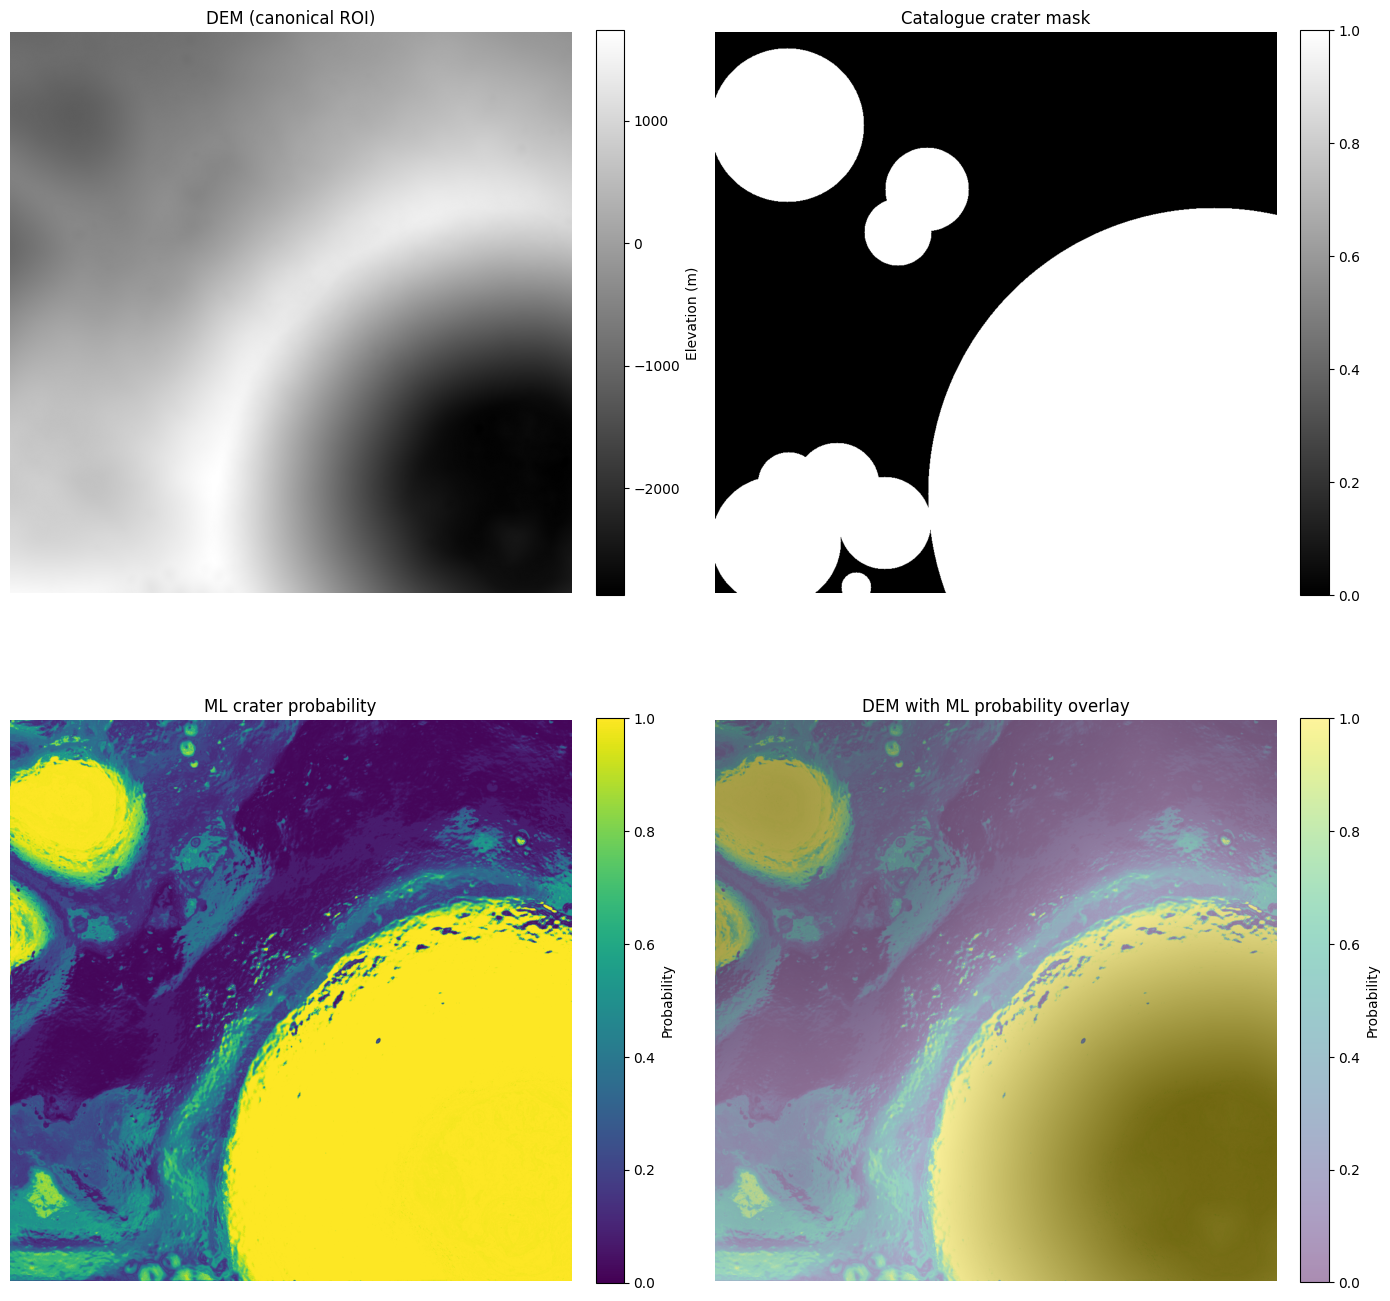

In [5]:

# ------------------------------------------------------------------
# 3) Main visual check
# ------------------------------------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# DEM
im0 = axes[0, 0].imshow(dem_m, origin="upper", cmap="gray")
axes[0, 0].set_title("DEM (canonical ROI)")
axes[0, 0].axis("off")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label="Elevation (m)")

# Crater mask
im1 = axes[0, 1].imshow(crater_mask, origin="upper", cmap="gray")
axes[0, 1].set_title("Catalogue crater mask")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

# ML probability map
im2 = axes[1, 0].imshow(crater_proba, origin="upper", vmin=0.0, vmax=1.0)
axes[1, 0].set_title("ML crater probability")
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04, label="Probability")

# DEM + ML overlay
axes[1, 1].imshow(dem_m, origin="upper", cmap="gray")
im3 = axes[1, 1].imshow(crater_proba, origin="upper", alpha=0.45, vmin=0.0, vmax=1.0)
axes[1, 1].set_title("DEM with ML probability overlay")
axes[1, 1].axis("off")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04, label="Probability")

plt.tight_layout()
plt.show()


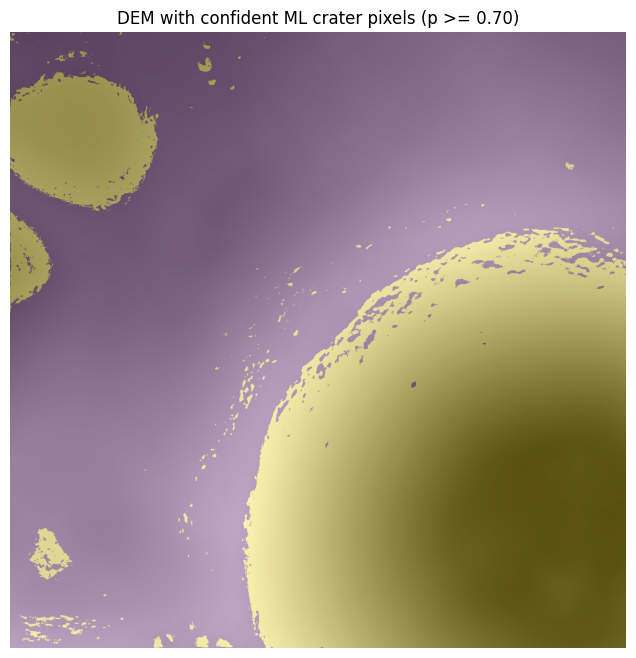

In [6]:

# ------------------------------------------------------------------
# 4) Optional: threshold preview for a quick “where is the model confident?”
# ------------------------------------------------------------------
threshold = 0.70
plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper", cmap="gray")
plt.imshow((crater_proba >= threshold).astype(np.uint8), origin="upper", alpha=0.35)
plt.title(f"DEM with confident ML crater pixels (p >= {threshold:.2f})")
plt.axis("off")
plt.show()


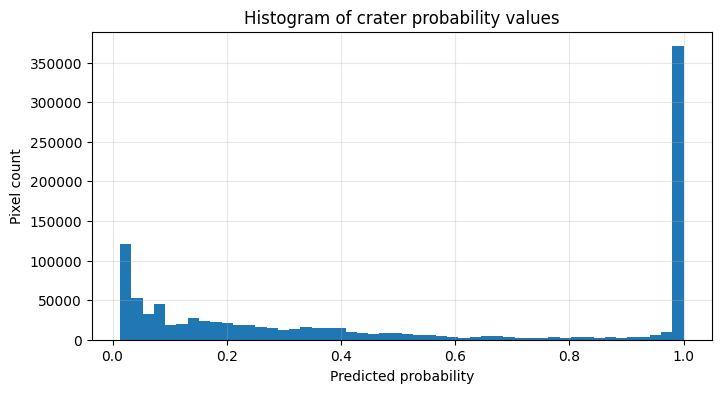

In [7]:

# ------------------------------------------------------------------
# 5) Optional: simple probability histogram
# ------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(crater_proba.ravel(), bins=50)
plt.title("Histogram of crater probability values")
plt.xlabel("Predicted probability")
plt.ylabel("Pixel count")
plt.grid(True, alpha=0.3)
plt.show()

Display vmin: -2772.40869140625
Display vmax: 1550.9871826171875


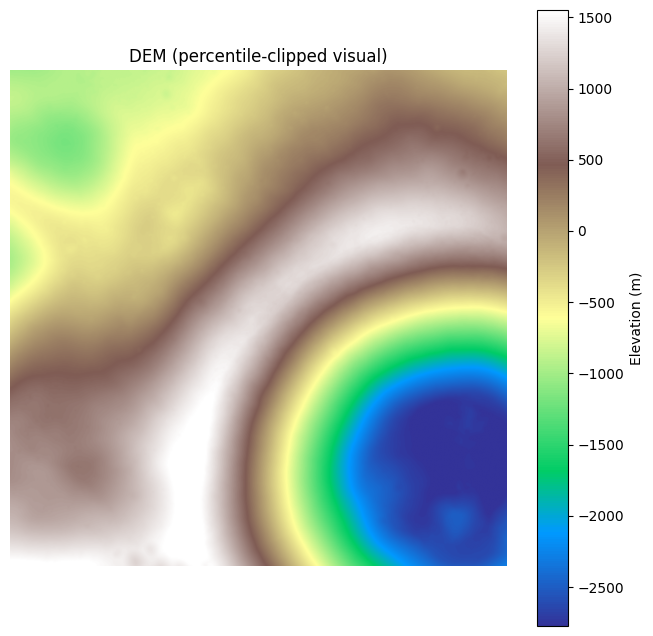

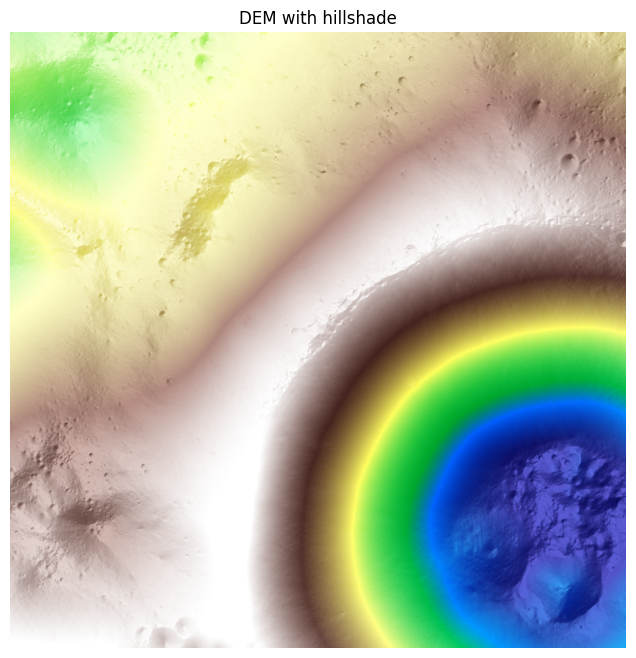

In [8]:
# - This is only for visual presentation, not for changing analysis data.
# - The DEM array itself is left untouched.
# - Main idea:
#     percentile clipping -> cleaner contrast
#     hillshade overlay   -> clearer terrain shape
#     better colormap     -> easier interpretation

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# dem_m already loaded earlier

# ------------------------------------------------------------
# 1) Robust display range
# ------------------------------------------------------------
vmin = np.percentile(dem_m, 2)
vmax = np.percentile(dem_m, 98)

print("Display vmin:", float(vmin))
print("Display vmax:", float(vmax))

# ------------------------------------------------------------
# 2) Plain improved DEM plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper", cmap="terrain", vmin=vmin, vmax=vmax)
plt.title("DEM (percentile-clipped visual)")
plt.colorbar(label="Elevation (m)")
plt.axis("off")
plt.show()

# ------------------------------------------------------------
# 3) Hillshade-enhanced DEM
# ------------------------------------------------------------
ls = LightSource(azdeg=315, altdeg=45)
dem_shaded = ls.shade(
    dem_m,
    cmap=plt.cm.terrain,
    vert_exag=1.0,
    blend_mode="soft",
    vmin=vmin,
    vmax=vmax,
)

plt.figure(figsize=(8, 8))
plt.imshow(dem_shaded, origin="upper")
plt.title("DEM with hillshade")
plt.axis("off")
plt.show()

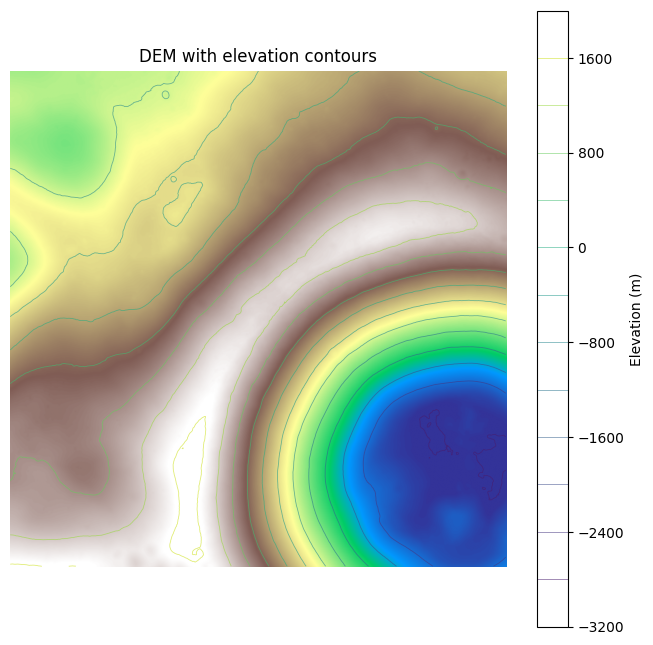

In [9]:
# contour overlay for structure readability

plt.figure(figsize=(8, 8))
plt.imshow(dem_m, origin="upper", cmap="terrain", vmin=vmin, vmax=vmax)
plt.contour(dem_m, levels=12, linewidths=0.6, alpha=0.6)
plt.title("DEM with elevation contours")
plt.colorbar(label="Elevation (m)")
plt.axis("off")
plt.show()